# Sales Data Analysis
Tenemos 50 datasets de fechas de ventas segun genero (hombre o mujer) agrupados por cada semana.
Preguntas: 
1. Representa las ventas diarias de las 50 semanas
2. El cambio drástico cuando se da?
3. El cambio en las ventas diarias es estadisticamente significativo? Cual es su p-valor?
4. ¿Los datos sugieren que el cambio en las ventas diarias pueda ser debido a un cambio en la proporcion de hombre vs mujer como compradores? Graficalo
5. Imagina que un dia se divida en 4 partes: Noche (12 AM- 6 AM) mañana (6-AM-12 PM), mediodia (12PM-6PM) y tarde (6PM-12AM). Cual es el porcentaje de ventas en cada franja durante las 50 semanas?.

1. Representa las ventas diarias de las 50 semanas

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [142]:
# Obtenemos todos los nombres de los csv del directorio ordenadamente
all = [pd.read_csv(filename) for filename in sorted(glob.glob("datasets/*.csv"))]
# Comprobamos que se han leido los 50 archivos
print(len(all))
# Se crea el dataset concatenando los archivos
df = pd.concat(all, axis=0)
df.head()

50


,sale_time,purchaser_gender
0,2012-10-01 01:42:22,female
1,2012-10-01 02:24:53,female
2,2012-10-01 02:25:40,female
3,2012-10-01 02:30:42,female
4,2012-10-01 02:51:32,male


In [143]:
df.sample(n=5)

,sale_time,purchaser_gender
2886,2013-09-13 04:54:47,male
2830,2013-08-23 05:42:41,female
1458,2013-09-11 06:14:17,male
646,2013-02-26 10:17:47,male
195,2013-07-08 09:52:24,female


Vemos que en la informacion del archivo se ve el año-mes-dia hora-minutos-segundos de cada venta con su correspondiente genero del comprador.
El problema es que si queremos por agrupar por día, hace falta cambiar el tipo de variable de "sale_time" porque es un string y hay que pasarlo a datetime. Se comprueba con dtypes

In [144]:
df.dtypes

sale_time           object
purchaser_gender    object
dtype: object

In [145]:
# Sobreescribimos la variable en formato datetime
df["sale_time"] = pd.to_datetime(df["sale_time"])

In [146]:
# Ahora el df sería 
print(df.head())
print(df.dtypes)

            sale_time purchaser_gender
0 2012-10-01 01:42:22           female
1 2012-10-01 02:24:53           female
2 2012-10-01 02:25:40           female
3 2012-10-01 02:30:42           female
4 2012-10-01 02:51:32             male
sale_time           datetime64[ns]
purchaser_gender            object
dtype: object


In [147]:
# Agrupamos las ventas por día
daily_sales = (
    df
    .set_index("sale_time")   # usar la fecha como índice
    .resample("D")            # agrupar por día
    .size()                   # contar ventas
    .reset_index(name="num_sales")
)
daily_sales.head()

,sale_time,num_sales
0,2012-10-01,514
1,2012-10-02,482
2,2012-10-03,499
3,2012-10-04,546
4,2012-10-05,476


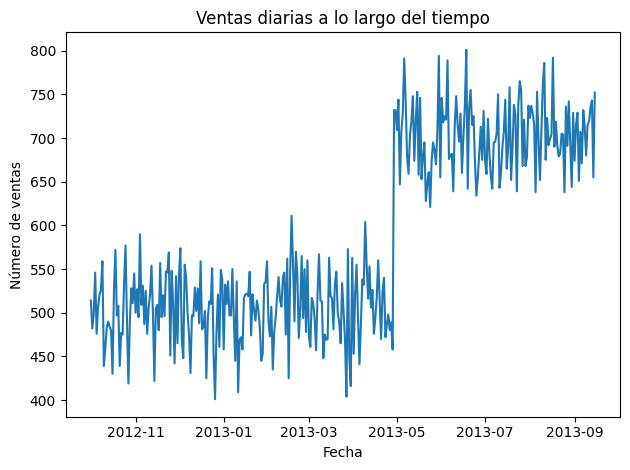

In [148]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(daily_sales["sale_time"], daily_sales["num_sales"])
plt.xlabel("Fecha")
plt.ylabel("Número de ventas")
plt.title("Ventas diarias a lo largo del tiempo")
plt.tight_layout()
plt.show()

2. ¿Cuando se da el cambio drastico?

In [149]:
# Creamos una nueva variable comparando con las ventas del dia anterior. El primer valor sera None por lo que hay que eliminar luego el ultimo para que cuadren
daily_sales["ventas_dia_anterior"] = [None] + daily_sales["num_sales"].to_list()[:-1]
daily_sales["diferencia_dia_anterior"] = (daily_sales["ventas_dia_anterior"] - daily_sales["num_sales"]).abs()
daily_sales.head()

,sale_time,num_sales,ventas_dia_anterior,diferencia_dia_anterior
0,2012-10-01,514,NaN,NaN
1,2012-10-02,482,514.0,32.0
2,2012-10-03,499,482.0,17.0
3,2012-10-04,546,499.0,47.0
4,2012-10-05,476,546.0,70.0


In [150]:
max_diferencia = daily_sales["diferencia_dia_anterior"].idxmax()
print(daily_sales.loc[[max_diferencia]])

diferencia_media = round(daily_sales["diferencia_dia_anterior"].mean(), 2)
print("\nMedia de diferencia diaria:", diferencia_media)

     sale_time  num_sales  ventas_dia_anterior  diferencia_dia_anterior
210 2013-04-29        732                458.0                    274.0

Media de diferencia diaria: 46.03


3. ¿El cambio en las ventas diarias es estadisticamente significativo? ¿Cual es su p-valor?

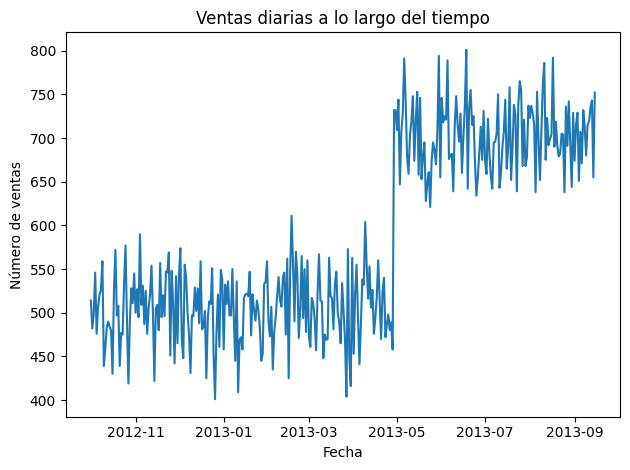

In [151]:
plt.figure()
plt.plot(daily_sales["sale_time"], daily_sales["num_sales"])
plt.xlabel("Fecha")
plt.ylabel("Número de ventas")
plt.title("Ventas diarias a lo largo del tiempo")
plt.tight_layout()
plt.show()

Recordando el grafico de ventas vemos que claramente hay dos grupos de datos: antes y despues del 2013-04-29. Son muestras independientes porque no tienen relacion entre ellas. Entonces mediremos con la prueba t para ver si existe una diferencia entre las medias de ambos grupos. Para la prueba t de muestras independientes: 
 - H0: u1=u2 es decir, que no hay diferencia entre las muestras.
 - H1: u1!=u2 es decir, existe diferencia entre las muestras 

In [152]:
daily_sales.head()

,sale_time,num_sales,ventas_dia_anterior,diferencia_dia_anterior
0,2012-10-01,514,NaN,NaN
1,2012-10-02,482,514.0,32.0
2,2012-10-03,499,482.0,17.0
3,2012-10-04,546,499.0,47.0
4,2012-10-05,476,546.0,70.0


In [153]:
from scipy import stats
# Lo primero es dividir el dataset a partir de la fecha de inflexion:

fecha_cambio = pd.Timestamp("2013-04-29")
antes = daily_sales[daily_sales["sale_time"] < fecha_cambio]["num_sales"]
despues = daily_sales[daily_sales["sale_time"]>= fecha_cambio]["num_sales"]

t_valor, p_valor = stats.ttest_ind(antes, despues, equal_var=False)
print(t_valor, p_valor)


-45.943533193935615 3.487246853115062e-138


El valor p obtenido es mucho menor que 0.01 por lo que podemos rechazar la hipotesis nula y decir que existe una diferencia muy significativa a partir del 2013-04-29 en las ventas diarias por lo que merece la pena seguir analizandolo

4. ¿Los datos sugieren que el cambio en las ventas diarias pueda ser debido a un cambio en la proporcion de hombre vs mujer como compradores? Graficalo

In [154]:
df["sales_day"] = df["sale_time"].dt.date
df.head()

,sale_time,purchaser_gender,sales_day
0,2012-10-01 01:42:22,female,2012-10-01
1,2012-10-01 02:24:53,female,2012-10-01
2,2012-10-01 02:25:40,female,2012-10-01
3,2012-10-01 02:30:42,female,2012-10-01
4,2012-10-01 02:51:32,male,2012-10-01


In [155]:
# Agrupamos las ventas por día y genero
daily_gender_sales = (
    df
    .groupby(["sales_day","purchaser_gender"]) #como una lista
    .size()                                    # contar ventas
    .reset_index(name="num_sales")
)
daily_gender_sales.head()

,sales_day,purchaser_gender,num_sales
0,2012-10-01,female,413
1,2012-10-01,male,101
2,2012-10-02,female,379
3,2012-10-02,male,103
4,2012-10-03,female,386


In [156]:
# Pivoteamos la tabla
daily_gender_pivot = (
    daily_gender_sales
    .pivot(index="sales_day", columns="purchaser_gender", values="num_sales")
    .fillna(0)
    .reset_index()

)
daily_gender_pivot.head()

purchaser_gender,sales_day,female,male
0,2012-10-01,413,101
1,2012-10-02,379,103
2,2012-10-03,386,113
3,2012-10-04,432,114
4,2012-10-05,368,108


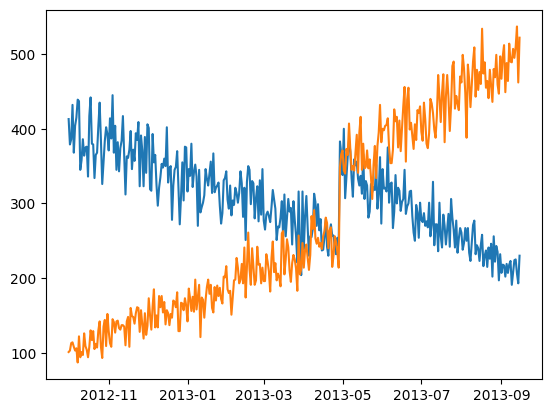

In [157]:
plt.figure()
plt.plot(daily_gender_pivot["sales_day"], daily_gender_pivot["female"])
plt.plot(daily_gender_pivot["sales_day"], daily_gender_pivot["male"])
plt.show()


Vemos que las compras de los hombres van ascendiendo y las de las mujeres descendiendo. Tienen correlacion negativa importante pero en la fecha ambas tienen un cambio drastico que no se puede explicar. Quiza por alguna campaña de marketing o causa externa.

#### 5. Imagina que un dia se divida en 4 partes: Noche (12 AM- 6 AM) mañana (6-AM-12 PM), mediodia (12PM-6PM) y tarde (6PM-12AM). Cual es el porcentaje de ventas en cada franja durante las 50 semanas?.

In [158]:
# Ahora extraemos la hora de la fecha para hacer los 4 grupos.
df["sales_hour"] = df["sale_time"].dt.hour
df.head()

,sale_time,purchaser_gender,sales_day,sales_hour
0,2012-10-01 01:42:22,female,2012-10-01,1
1,2012-10-01 02:24:53,female,2012-10-01,2
2,2012-10-01 02:25:40,female,2012-10-01,2
3,2012-10-01 02:30:42,female,2012-10-01,2
4,2012-10-01 02:51:32,male,2012-10-01,2


In [159]:
bins = (0, 6, 12, 18, 24)
labels = ["Noche", "Mañana", "Mediodía", "Tarde"]

df["franja_dia"] = pd.cut(
    df["sales_hour"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df.head()

,sale_time,purchaser_gender,sales_day,sales_hour,franja_dia
0,2012-10-01 01:42:22,female,2012-10-01,1,Noche
1,2012-10-01 02:24:53,female,2012-10-01,2,Noche
2,2012-10-01 02:25:40,female,2012-10-01,2,Noche
3,2012-10-01 02:30:42,female,2012-10-01,2,Noche
4,2012-10-01 02:51:32,male,2012-10-01,2,Noche


In [160]:
# Agrupamos por franja horaria las ventas
ventas_franja = (
    df
    .groupby("franja_dia")
    .size()
    .reset_index(name="ventas_franja")
)
ventas_franja.head()

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_16404\3085328021.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("franja_dia")


,franja_dia,ventas_franja
0,Noche,18306
1,Mañana,62870
2,Mediodía,80533
3,Tarde,42620


In [161]:
# Finalmente calculamos el porcentaje relativo
ventas_franja["porcentaje"] = ventas_franja["ventas_franja"]/ventas_franja["ventas_franja"].sum()*100

In [162]:
ventas_franja

,franja_dia,ventas_franja,porcentaje
0,Noche,18306,8.959081
1,Mañana,62870,30.769005
2,Mediodía,80533,39.413397
3,Tarde,42620,20.858517


El mediodia es cuando más compras se registran, seguidamente de la mañana y de la tarde. La noche es la franja de menos ventas como cabria esperar, con menos de la mitad del registro que la penultima franja con  menor ventas.

In [163]:
df["sale_time"].dt.hour.value_counts().sort_index()

sale_time
0       268
1      1045
2      2284
3      3518
4      4944
5      6247
6      7709
7      9072
8      9939
9     11224
10    11890
11    13036
12    13443
13    13798
14    13861
15    13750
16    13269
17    12412
18    11653
19    10029
20     8489
21     6740
22     4202
23     1507
Name: count, dtype: int64